# Kinematic Reconstruction Training

This notebook uses ARTIST's KinematicReconstructor to optimize heliostat kinematic parameters using the PAINT benchmark dataset, then evaluates flux image prediction accuracy on the test set.

## 1. Imports and Setup

In [1]:
import logging
import pathlib
from collections import defaultdict

import h5py
import pandas as pd
import torch
from matplotlib import pyplot as plt

import paint.util.paint_mappings as paint_mappings
from artist.core.heliostat_ray_tracer import HeliostatRayTracer
from artist.core.kinematic_reconstructor import KinematicReconstructor
from artist.core.loss_functions import FocalSpotLoss
from artist.data_parser.paint_calibration_parser import PaintCalibrationDataParser
from artist.scenario.scenario import Scenario
from artist.util import config_dictionary, set_logger_config
from artist.util.environment_setup import get_device, setup_distributed_environment

# Set random seeds for reproducibility
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Setup logging
set_logger_config()
log = logging.getLogger(__name__)

print("Imports completed successfully!")

Imports completed successfully!


## 2. Helper Functions

In [2]:
def build_heliostat_data_mapping(
    benchmark_csv: pathlib.Path,
    calibration_properties_dir: pathlib.Path,
    flux_image_dir: pathlib.Path,
    split: str = "train",
) -> list[tuple[str, list[pathlib.Path], list[pathlib.Path]]]:
    """
    Build the heliostat_data_mapping from the benchmark CSV file.

    Parameters
    ----------
    benchmark_csv : pathlib.Path
        Path to the benchmark split CSV file.
    calibration_properties_dir : pathlib.Path
        Base directory containing calibration properties JSON files.
    flux_image_dir : pathlib.Path
        Base directory containing flux image PNG files.
    split : str
        Which split to use: "train", "validation", or "test".

    Returns
    -------
    list[tuple[str, list[pathlib.Path], list[pathlib.Path]]]
        List of tuples (heliostat_name, calibration_paths, flux_paths).
    """
    # Read the benchmark CSV
    df = pd.read_csv(benchmark_csv)

    # Filter by split
    df_split = df[df["Split"] == split]

    log.info(f"Building heliostat_data_mapping for split '{split}'")
    log.info(f"Total samples in split: {len(df_split)}")

    # Group by heliostat
    heliostat_groups = defaultdict(list)
    for _, row in df_split.iterrows():
        measurement_id = row["Id"]
        heliostat_id = row["HeliostatId"]
        heliostat_groups[heliostat_id].append(measurement_id)

    log.info(f"Number of unique heliostats: {len(heliostat_groups)}")

    # Build the mapping
    heliostat_data_mapping = []
    for heliostat_id, measurement_ids in sorted(heliostat_groups.items()):
        calibration_paths = []
        flux_paths = []

        for mid in measurement_ids:
            cal_path = calibration_properties_dir / split / f"{mid}-calibration-properties.json"
            flux_path = flux_image_dir / split / f"{mid}-flux.png"

            # Only include if both files exist
            if cal_path.exists() and flux_path.exists():
                calibration_paths.append(cal_path)
                flux_paths.append(flux_path)

        if calibration_paths:
            heliostat_data_mapping.append((heliostat_id, calibration_paths, flux_paths))

    log.info(f"Built mapping for {len(heliostat_data_mapping)} heliostats")

    return heliostat_data_mapping

In [21]:
def evaluate_flux_accuracy(
    scenario: Scenario,
    heliostat_data_mapping: list[tuple[str, list[pathlib.Path], list[pathlib.Path]]],
    data_parser: PaintCalibrationDataParser,
    device: torch.device,
    bitmap_resolution: torch.Tensor = torch.tensor([256, 256]),
    ray_tracing_batch_size: int = 32,
) -> dict:
    """
    Evaluate flux image prediction accuracy after kinematic reconstruction.

    Parameters
    ----------
    scenario : Scenario
        The scenario with optimized kinematic parameters.
    heliostat_data_mapping : list
        Mapping of heliostats to their calibration data.
    data_parser : PaintCalibrationDataParser
        Parser for calibration data.
    device : torch.device
        Device to run computations on.
    bitmap_resolution : torch.Tensor
        Resolution of the flux bitmaps.
    ray_tracing_batch_size : int
        Batch size for ray tracing (default: 32).

    Returns
    -------
    dict
        Dictionary containing evaluation metrics.
    """
    from artist.util.utils import get_center_of_mass
    from artist.util import index_mapping
    
    all_pixel_losses = []
    all_focal_spot_errors = []
    results_per_heliostat = {}

    for heliostat_group in scenario.heliostat_field.heliostat_groups:
        (
            measured_flux,
            focal_spots,
            incident_ray_directions,
            motor_positions,
            active_heliostats_mask,
            target_area_mask,
        ) = data_parser.parse_data_for_reconstruction(
            heliostat_data_mapping=heliostat_data_mapping,
            heliostat_group=heliostat_group,
            scenario=scenario,
            bitmap_resolution=bitmap_resolution,
            device=device,
        )

        if active_heliostats_mask.sum() == 0:
            continue

        # Activate heliostats
        heliostat_group.activate_heliostats(
            active_heliostats_mask=active_heliostats_mask,
            device=device,
        )

        # Align heliostats with incident ray directions
        heliostat_group.align_surfaces_with_incident_ray_directions(
            aim_points=scenario.target_areas.centers[target_area_mask],
            incident_ray_directions=incident_ray_directions,
            active_heliostats_mask=active_heliostats_mask,
            device=device,
        )

        # Create ray tracer
        ray_tracer = HeliostatRayTracer(
            scenario=scenario,
            heliostat_group=heliostat_group,
            blocking_active=False,
            batch_size=min(heliostat_group.number_of_active_heliostats, ray_tracing_batch_size),
            bitmap_resolution=bitmap_resolution.to(device),
        )

        # Trace rays to get predicted flux
        predicted_flux = ray_tracer.trace_rays(
            incident_ray_directions=incident_ray_directions,
            active_heliostats_mask=active_heliostats_mask,
            target_area_mask=target_area_mask,
            device=device,
        )

        # Compute pixel-wise MSE loss
        pixel_loss = ((predicted_flux - measured_flux) ** 2).mean(dim=[1, 2])
        all_pixel_losses.extend(pixel_loss.cpu().tolist())

        # Compute focal spot error (center of mass comparison)
        target_centers = scenario.target_areas.centers[target_area_mask]
        target_widths = scenario.target_areas.dimensions[target_area_mask][
            :, index_mapping.target_area_width
        ]
        target_heights = scenario.target_areas.dimensions[target_area_mask][
            :, index_mapping.target_area_height
        ]
        
        predicted_focal_spots = get_center_of_mass(
            bitmaps=predicted_flux,
            target_centers=target_centers,
            target_widths=target_widths,
            target_heights=target_heights,
            device=device,
        )
        
        # Compute Euclidean distance between predicted and measured focal spots
        focal_spot_error = torch.norm(predicted_focal_spots[:, :3] - focal_spots[:, :3], dim=1)
        all_focal_spot_errors.extend(focal_spot_error.cpu().tolist())

        # Store per-heliostat results
        heliostat_names = [
            name for name, _, _ in heliostat_data_mapping
            if name in heliostat_group.names
        ]
        for i, name in enumerate(heliostat_names):
            if i < len(pixel_loss):
                results_per_heliostat[name] = {
                    "pixel_mse": pixel_loss[i].item(),
                    "focal_spot_error_m": focal_spot_error[i].item() if i < len(focal_spot_error) else None,
                }

    # Compute aggregate metrics
    metrics = {
        "mean_pixel_mse": sum(all_pixel_losses) / len(all_pixel_losses) if all_pixel_losses else float("inf"),
        "mean_focal_spot_error_m": sum(all_focal_spot_errors) / len(all_focal_spot_errors) if all_focal_spot_errors else float("inf"),
        "max_focal_spot_error_m": max(all_focal_spot_errors) if all_focal_spot_errors else float("inf"),
        "min_focal_spot_error_m": min(all_focal_spot_errors) if all_focal_spot_errors else float("inf"),
        "num_samples_evaluated": len(all_pixel_losses),
        "per_heliostat": results_per_heliostat,
          }
    return metrics

In [ ]:
def visualize_flux_comparison(
    scenario: Scenario,
    heliostat_data_mapping: list[tuple[str, list[pathlib.Path], list[pathlib.Path]]],
    data_parser: PaintCalibrationDataParser,
    device: torch.device,
    output_dir: pathlib.Path = None,
    num_samples: int = 5,
    save_figures: bool = False,
):
    """
    Visualize comparison between predicted and measured flux images.

    Parameters
    ----------
    scenario : Scenario
        The scenario with optimized kinematic parameters.f
    heliostat_data_mapping : list
        Mapping of heliostats to their calibration data.
    data_parser : PaintCalibrationDataParser
        Parser for calibration data.
    device : torch.device
        Device to run computations on.
    output_dir : pathlib.Path
        Directory to save visualization images (only if save_figures=True).
    num_samples : int
        Number of samples to visualize.
    save_figures : bool
        Whether to save figures to disk.
    """
    if save_figures and output_dir is not None:
        output_dir.mkdir(parents=True, exist_ok=True)
    
    samples_visualized = 0

    for heliostat_group in scenario.heliostat_field.heliostat_groups:
        if samples_visualized >= num_samples:
            break

        (
            measured_flux,
            _,
            incident_ray_directions,
            _,
            active_heliostats_mask,
            target_area_mask,
        ) = data_parser.parse_data_for_reconstruction(
            heliostat_data_mapping=heliostat_data_mapping,
            heliostat_group=heliostat_group,
            scenario=scenario,
            bitmap_resolution=torch.tensor([256, 256]),
            device=device,
        )

        if active_heliostats_mask.sum() == 0:
            continue

        # Activate and align heliostats
        heliostat_group.activate_heliostats(
            active_heliostats_mask=active_heliostats_mask,
            device=device,
        )
        heliostat_group.align_surfaces_with_incident_ray_directions(
            aim_points=scenario.target_areas.centers[target_area_mask],
            incident_ray_directions=incident_ray_directions,
            active_heliostats_mask=active_heliostats_mask,
            device=device,
        )

        # Ray trace
        ray_tracer = HeliostatRayTracer(
            scenario=scenario,
            heliostat_group=heliostat_group,
            blocking_active=False,
            batch_size=min(heliostat_group.number_of_active_heliostats, 32),
            bitmap_resolution=torch.tensor([256, 256], device=device),
        )

        predicted_flux = ray_tracer.trace_rays(
            incident_ray_directions=incident_ray_directions,
            active_heliostats_mask=active_heliostats_mask,
            target_area_mask=target_area_mask,
            device=device,
        )

        # Visualize
        for i in range(min(len(predicted_flux), num_samples - samples_visualized)):
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))

            im0 = axes[0].imshow(predicted_flux[i].cpu().detach(), cmap="hot")
            axes[0].set_title("Predicted Flux")
            axes[0].axis("off")
            plt.colorbar(im0, ax=axes[0], fraction=0.046)

            im1 = axes[1].imshow(measured_flux[i].cpu().detach(), cmap="hot")
            axes[1].set_title("Measured Flux")
            axes[1].axis("off")
            plt.colorbar(im1, ax=axes[1], fraction=0.046)

            diff = (predicted_flux[i] - measured_flux[i]).cpu().detach()
            im2 = axes[2].imshow(diff, cmap="coolwarm", vmin=-diff.abs().max(), vmax=diff.abs().max())
            axes[2].set_title("Difference (Predicted - Measured)")
            axes[2].axis("off")
            plt.colorbar(im2, ax=axes[2], fraction=0.046)

            plt.tight_layout()
            
            if save_figures and output_dir is not None:
                plt.savefig(output_dir / f"flux_comparison_{samples_visualized}.png", dpi=150)
            
            plt.show()

            samples_visualized += 1
            if samples_visualized >= num_samples:
                break

    print(f"Visualized {samples_visualized} flux comparison images")

## 3. Configuration

In [5]:
# Paths - adjust these as needed
BASE_DIR =  pathlib.Path.cwd().parent
SRC_DIR = BASE_DIR / "src"
BENCHMARK_NAME = "benchmark_split-balanced_train-10_validation-30"
BENCHMARK_DIR = SRC_DIR / "paint_benchmarks"
SCENARIO_PATH = BASE_DIR / "scenarios" / "all_heliostats_scenario" / "all_heliostats_scenario.h5"
OUTPUT_DIR = SRC_DIR / "kinematic_reconstruction_results"

# Benchmark file paths
BENCHMARK_CSV = BENCHMARK_DIR / "splits" / f"{BENCHMARK_NAME}.csv"
CALIBRATION_PROPERTIES_DIR = BENCHMARK_DIR / "datasets" / BENCHMARK_NAME / "calibration_properties"
FLUX_IMAGE_DIR = BENCHMARK_DIR / "datasets" / BENCHMARK_NAME / "flux_image"

# Training configuration - REDUCED to avoid shape mismatch issues
SAMPLE_LIMIT_PER_HELIOSTAT = 8  # Reduced from 10 to 8 (must divide evenly into batch_size)
CENTROID_METHOD = paint_mappings.UTIS_KEY  # or paint_mappings.HELIOS_KEY

print(f"Base directory: {BASE_DIR}")
print(f"Benchmark CSV: {BENCHMARK_CSV}")
print(f"Scenario path: {SCENARIO_PATH}")
print(f"\nPaths exist:")
print(f"  Benchmark CSV: {BENCHMARK_CSV.exists()}")
print(f"  Scenario: {SCENARIO_PATH.exists()}")
print(f"  Calibration dir: {CALIBRATION_PROPERTIES_DIR.exists()}")
print(f"  Flux image dir: {FLUX_IMAGE_DIR.exists()}")

Base directory: /Users/alexandru/Master Thesis/master-thesis
Benchmark CSV: /Users/alexandru/Master Thesis/master-thesis/src/paint_benchmarks/splits/benchmark_split-balanced_train-10_validation-30.csv
Scenario path: /Users/alexandru/Master Thesis/master-thesis/scenarios/all_heliostats_scenario/all_heliostats_scenario.h5

Paths exist:
  Benchmark CSV: True
  Scenario: True
  Calibration dir: True
  Flux image dir: True


In [6]:
# Device setup
device = get_device()
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

[2026-01-27 12:47:49,131][artist.util.environment_setup][INFO] - No device type provided. The device will default to GPU based on availability and OS, otherwise to CPU.
[2026-01-27 12:47:49,132][artist.util.environment_setup][WARNING] - Setting device to CPU. ARTIST only supports CPU for MacOS.
Using device: cpu


## 4. Build Heliostat Data Mappings

In [7]:
print("Building heliostat data mappings...")

train_mapping = build_heliostat_data_mapping(
    benchmark_csv=BENCHMARK_CSV,
    calibration_properties_dir=CALIBRATION_PROPERTIES_DIR,
    flux_image_dir=FLUX_IMAGE_DIR,
    split="train",
)

test_mapping = build_heliostat_data_mapping(
    benchmark_csv=BENCHMARK_CSV,
    calibration_properties_dir=CALIBRATION_PROPERTIES_DIR,
    flux_image_dir=FLUX_IMAGE_DIR,
    split="test",
)

print(f"\nTrain mapping: {len(train_mapping)} heliostats")
print(f"Test mapping: {len(test_mapping)} heliostats")

Building heliostat data mappings...

Train mapping: 1315 heliostats
Test mapping: 1315 heliostats


In [8]:
# Inspect the mappings
print("Sample of train mapping:")
for heliostat_id, cal_paths, flux_paths in train_mapping[:3]:
    print(f"  Heliostat: {heliostat_id}, Calibration files: {len(cal_paths)}, Flux files: {len(flux_paths)}")
    print("cal_paths:", cal_paths[0])
    print("flux_paths:", flux_paths[0])

Sample of train mapping:
  Heliostat: AA23, Calibration files: 9, Flux files: 9
cal_paths: /Users/alexandru/Master Thesis/master-thesis/src/paint_benchmarks/datasets/benchmark_split-balanced_train-10_validation-30/calibration_properties/train/203321-calibration-properties.json
flux_paths: /Users/alexandru/Master Thesis/master-thesis/src/paint_benchmarks/datasets/benchmark_split-balanced_train-10_validation-30/flux_image/train/203321-flux.png
  Heliostat: AA24, Calibration files: 10, Flux files: 10
cal_paths: /Users/alexandru/Master Thesis/master-thesis/src/paint_benchmarks/datasets/benchmark_split-balanced_train-10_validation-30/calibration_properties/train/134053-calibration-properties.json
flux_paths: /Users/alexandru/Master Thesis/master-thesis/src/paint_benchmarks/datasets/benchmark_split-balanced_train-10_validation-30/flux_image/train/134053-flux.png
  Heliostat: AA25, Calibration files: 10, Flux files: 10
cal_paths: /Users/alexandru/Master Thesis/master-thesis/src/paint_benchmar

## 5. Create Data Parsers

In [9]:
# Parser for training (with sample limit)
train_data_parser = PaintCalibrationDataParser(
    sample_limit=SAMPLE_LIMIT_PER_HELIOSTAT,
    centroid_extraction_method=CENTROID_METHOD,
)

# Parser for evaluation (reduced to avoid memory issues)
eval_data_parser = PaintCalibrationDataParser(
    sample_limit=10,  # Reduced from 50 to 10 to avoid memory crashes
    centroid_extraction_method=CENTROID_METHOD,
)

print(f"Train parser sample limit: {SAMPLE_LIMIT_PER_HELIOSTAT}")
print(f"Eval parser sample limit: 10")
print(f"Centroid method: {CENTROID_METHOD}")

Train parser sample limit: 8
Eval parser sample limit: 10
Centroid method: UTIS


## 6. Setup Data Dictionary

In [10]:
data = {
    config_dictionary.data_parser: train_data_parser,
    config_dictionary.heliostat_data_mapping: train_mapping,
}

print("Data dictionary created")

Data dictionary created


## 7. Load Scenario

In [11]:
print(f"Loading scenario from: {SCENARIO_PATH}")

number_of_heliostat_groups = Scenario.get_number_of_heliostat_groups_from_hdf5(
    scenario_path=SCENARIO_PATH
)
print(f"Number of heliostat groups: {number_of_heliostat_groups}")

Loading scenario from: /Users/alexandru/Master Thesis/master-thesis/scenarios/all_heliostats_scenario/all_heliostats_scenario.h5
Number of heliostat groups: 1


## 8. Optimization Configuration

In [12]:
scheduler = config_dictionary.reduce_on_plateau
scheduler_parameters = {
    config_dictionary.gamma: 0.9,
    config_dictionary.min: 1e-6,
    config_dictionary.max: 1e-3,
    config_dictionary.reduce_factor: 0.1,
    config_dictionary.patience: 5,  # Reduced to fit 20 epoch limit
    config_dictionary.threshold: 1e-4,
    config_dictionary.cooldown: 3,  # Reduced proportionally
}

optimization_configuration = {
    config_dictionary.initial_learning_rate: 0.0005,
    config_dictionary.tolerance: 0.0001,
    config_dictionary.max_epoch: 20,
    config_dictionary.batch_size: 8,
    config_dictionary.log_step: 5,  # Log every 5 epochs instead of 10
    config_dictionary.early_stopping_delta: 1e-5,
    config_dictionary.early_stopping_patience: 7,  # Reduced to ~35% of max epochs
    config_dictionary.scheduler: scheduler,
    config_dictionary.scheduler_parameters: scheduler_parameters,
}

print("Optimization configuration:")
for key, value in optimization_configuration.items():
    if key != config_dictionary.scheduler_parameters:
        print(f"  {key}: {value}")

Optimization configuration:
  initial_learning_rate: 0.0005
  tolerance: 0.0001
  max_epoch: 20
  batch_size: 8
  log_step: 5
  early_stopping_delta: 1e-05
  early_stopping_patience: 7
  scheduler: reduce_on_plateau


## 9. Run Kinematic Reconstruction

This is the main training loop. It may take a while to complete.

In [13]:
# Setup distributed environment and run reconstruction
final_loss_per_heliostat = None

try:
    with setup_distributed_environment(
        number_of_heliostat_groups=number_of_heliostat_groups,
        device=device,
    ) as ddp_setup:
        device = ddp_setup[config_dictionary.device]

        # Load the scenario
        with h5py.File(SCENARIO_PATH, "r") as scenario_file:
            scenario = Scenario.load_scenario_from_hdf5(
                scenario_file=scenario_file, device=device
            )

        print("Scenario loaded successfully")
        print(f"Number of heliostats in scenario: {scenario.heliostat_field.number_of_heliostat_groups}")
        
        # Check GPU memory before training
        if torch.cuda.is_available():
            print(f"GPU memory allocated: {torch.cuda.memory_allocated(device) / 1e9:.2f} GB")
            print(f"GPU memory reserved: {torch.cuda.memory_reserved(device) / 1e9:.2f} GB")

        # Create kinematic reconstructor
        kinematic_reconstructor = KinematicReconstructor(
            ddp_setup=ddp_setup,
            scenario=scenario,
            data=data,
            optimization_configuration=optimization_configuration,
            reconstruction_method=config_dictionary.kinematic_reconstruction_raytracing,
        )

        # Create loss function
        loss_definition = FocalSpotLoss(scenario=scenario)

        print("\nStarting kinematic reconstruction...")

        # Run reconstruction
        final_loss_per_heliostat = kinematic_reconstructor.reconstruct_kinematic(
            loss_definition=loss_definition, device=device
        )

    print("\nReconstruction complete!")
    
except Exception as e:
    print("\n" + "=" * 60)
    print("ERROR: Training crashed!")
    print("=" * 60)
    print(f"Error type: {type(e).__name__}")
    print(f"Error message: {str(e)}")
    print("=" * 60)
    
    # Print memory info if GPU crash
    if torch.cuda.is_available():
        try:
            print(f"\nGPU memory allocated: {torch.cuda.memory_allocated(device) / 1e9:.2f} GB")
            print(f"GPU memory reserved: {torch.cuda.memory_reserved(device) / 1e9:.2f} GB")
            print("Attempting to clear GPU cache...")
            torch.cuda.empty_cache()
            print("GPU cache cleared")
        except:
            print("Could not retrieve GPU memory information")
    
    # Print full traceback
    import traceback
    print("\nFull traceback:")
    traceback.print_exc()
    
    # Re-raise to see the full error
    raise

[2026-01-27 12:47:50,447][artist.util.environment_setup][INFO] - Distributed Mode disabled. Running in single-device mode.
[2026-01-27 12:47:50,448][artist.scenario.scenario][INFO] - Loading an ARTIST scenario HDF5 file. This scenario file is version 1.0.
[2026-01-27 12:47:50,449][artist.field.tower_target_areas][INFO] - Loading the tower target areas from an HDF5 file.
[2026-01-27 12:47:50,450][artist.field.tower_target_areas][WARNING] - No curvature in the east direction set for the multi_focus_tower!
[2026-01-27 12:47:50,450][artist.field.tower_target_areas][WARNING] - No curvature in the up direction set for the multi_focus_tower!
[2026-01-27 12:47:50,451][artist.field.tower_target_areas][WARNING] - No curvature in the east direction set for the receiver!
[2026-01-27 12:47:50,451][artist.field.tower_target_areas][WARNING] - No curvature in the up direction set for the receiver!
[2026-01-27 12:47:50,452][artist.field.tower_target_areas][WARNING] - No curvature in the east direction 

## 10. Analyze Training Results

In [18]:
print(f"Final loss per heliostat shape: {final_loss_per_heliostat.shape}")

# Filter out infinite losses (heliostats without data)
valid_losses = final_loss_per_heliostat[final_loss_per_heliostat != float("inf")]

if len(valid_losses) > 0:
    print(f"\nTraining Results:")
    print(f"  Number of trained heliostats: {len(valid_losses)}")
    print(f"  Mean loss: {valid_losses.mean().item():.6f}")
    print(f"  Min loss: {valid_losses.min().item():.6f}")
    print(f"  Max loss: {valid_losses.max().item():.6f}")
    print(f"  Std loss: {valid_losses.std().item():.6f}")

Final loss per heliostat shape: torch.Size([137])

Training Results:
  Number of trained heliostats: 132
  Mean loss: 0.434172
  Min loss: 0.256176
  Max loss: 1.172176
  Std loss: 0.140536


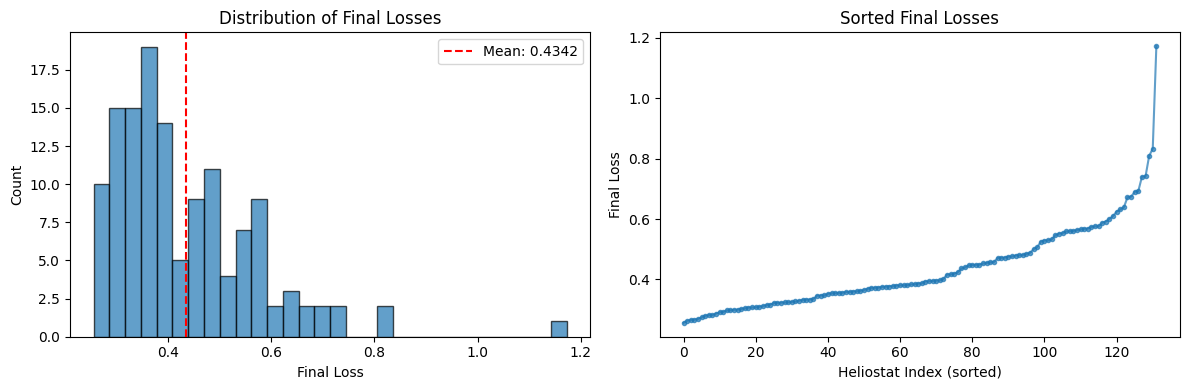

In [19]:
# Plot loss distribution
if len(valid_losses) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram
    axes[0].hist(valid_losses.detach().cpu().numpy(), bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Final Loss')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Distribution of Final Losses')
    axes[0].axvline(valid_losses.mean().item(), color='red', linestyle='--', label=f'Mean: {valid_losses.mean().item():.4f}')
    axes[0].legend()
    
    # Sorted losses
    sorted_losses = valid_losses.detach().cpu().numpy()
    sorted_losses.sort()
    axes[1].plot(sorted_losses, marker='o', markersize=3, linestyle='-', alpha=0.7)
    axes[1].set_xlabel('Heliostat Index (sorted)')
    axes[1].set_ylabel('Final Loss')
    axes[1].set_title('Sorted Final Losses')
    
    plt.tight_layout()
    plt.show()

## 11. Evaluate on Test Set

In [22]:
print("Evaluating on test set...")

test_metrics = evaluate_flux_accuracy(
    scenario=scenario,
    heliostat_data_mapping=test_mapping,
    data_parser=eval_data_parser,
    device=device,
)

print("\n" + "=" * 60)
print("TEST SET EVALUATION RESULTS")
print("=" * 60)
print(f"Number of samples evaluated: {test_metrics['num_samples_evaluated']}")
print(f"Mean pixel MSE: {test_metrics['mean_pixel_mse']:.6f}")
print(f"Mean focal spot error: {test_metrics['mean_focal_spot_error_m']:.4f} m")
print(f"Min focal spot error: {test_metrics['min_focal_spot_error_m']:.4f} m")
print(f"Max focal spot error: {test_metrics['max_focal_spot_error_m']:.4f} m")
print("=" * 60)

Evaluating on test set...
[2026-01-27 13:11:20,067][artist.data_parser.calibration_data_parser][INFO] - Rank 0: Beginning extraction of flux distributions from .png files.
[2026-01-27 13:11:27,202][artist.data_parser.calibration_data_parser][INFO] - Rank 0: Loading measured flux density distributions complete.
[2026-01-27 13:11:27,212][artist.data_parser.paint_calibration_parser][INFO] - Beginning extraction of calibration properties data from PAINT file.
[2026-01-27 13:11:27,329][artist.data_parser.paint_calibration_parser][INFO] - Loading calibration properties data complete.

TEST SET EVALUATION RESULTS
Number of samples evaluated: 1320
Mean pixel MSE: 0.058508
Mean focal spot error: 0.5393 m
Min focal spot error: 0.1836 m
Max focal spot error: 3.3587 m


In [23]:
# Display per-heliostat results
if test_metrics['per_heliostat']:
    per_heliostat_df = pd.DataFrame.from_dict(test_metrics['per_heliostat'], orient='index')
    per_heliostat_df = per_heliostat_df.sort_values('focal_spot_error_m')
    print("\nPer-heliostat results (sorted by focal spot error):")
    display(per_heliostat_df)


Per-heliostat results (sorted by focal spot error):


,pixel_mse,focal_spot_error_m
AC37,0.035405,0.186874
AC30,0.041876,0.194709
AB30,0.043861,0.206187
AD29,0.043615,0.219574
BA39,0.051021,0.221489
...,...,...
BD39,0.088377,1.005433
BB39,0.028061,1.027169
AC35,0.034420,1.043228
AC45,0.095985,1.406989


## 12. Visualize Flux Comparisons

Generating flux comparison visualizations...
[2026-01-27 13:21:37,901][artist.data_parser.calibration_data_parser][INFO] - Rank 0: Beginning extraction of flux distributions from .png files.
[2026-01-27 13:21:44,834][artist.data_parser.calibration_data_parser][INFO] - Rank 0: Loading measured flux density distributions complete.
[2026-01-27 13:21:44,836][artist.data_parser.paint_calibration_parser][INFO] - Beginning extraction of calibration properties data from PAINT file.
[2026-01-27 13:21:44,997][artist.data_parser.paint_calibration_parser][INFO] - Loading calibration properties data complete.


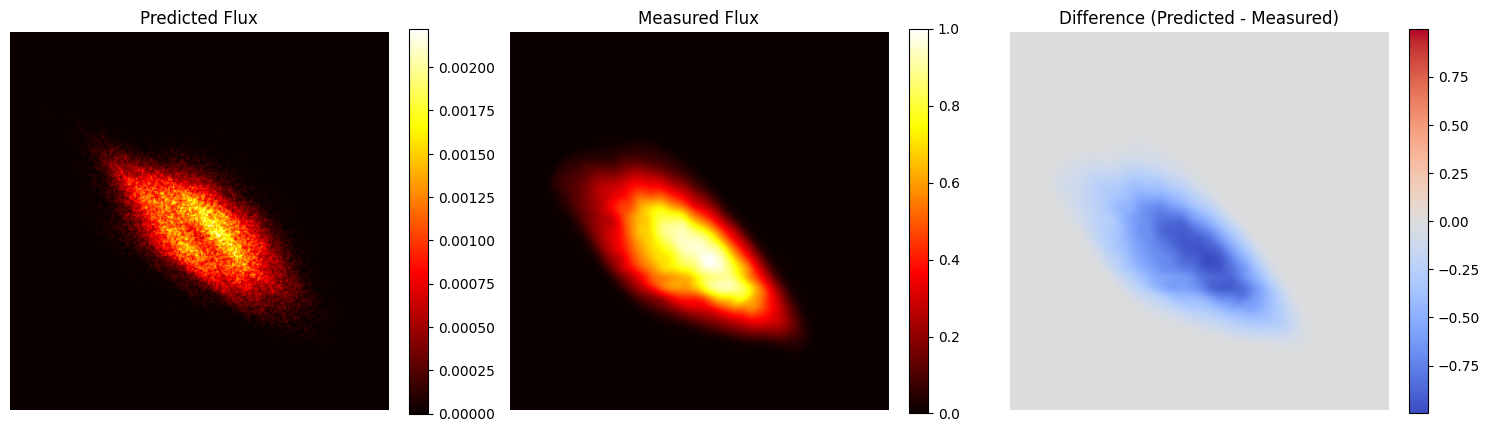

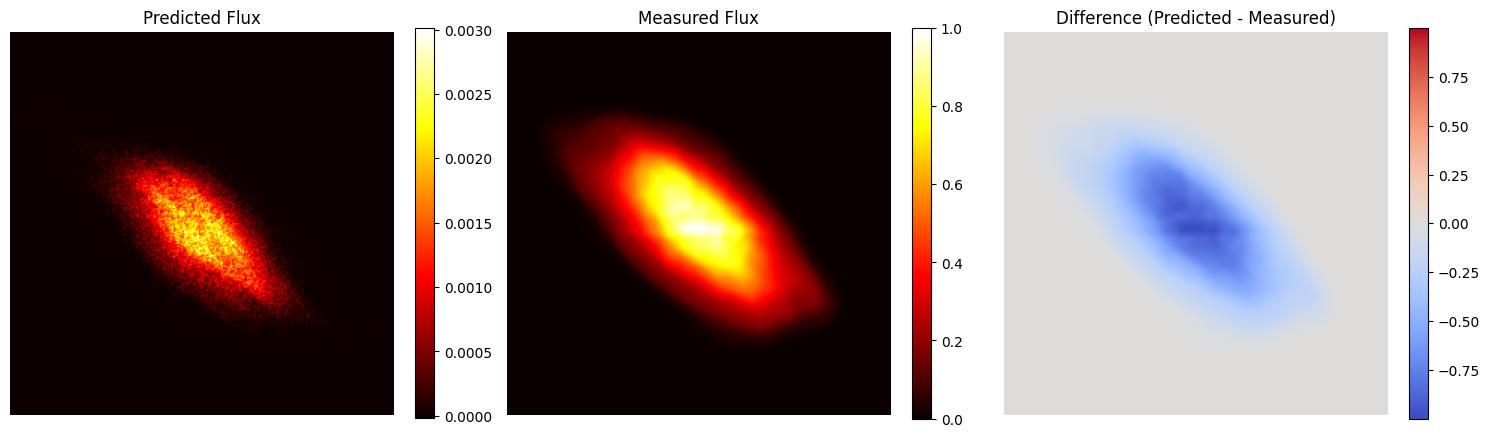

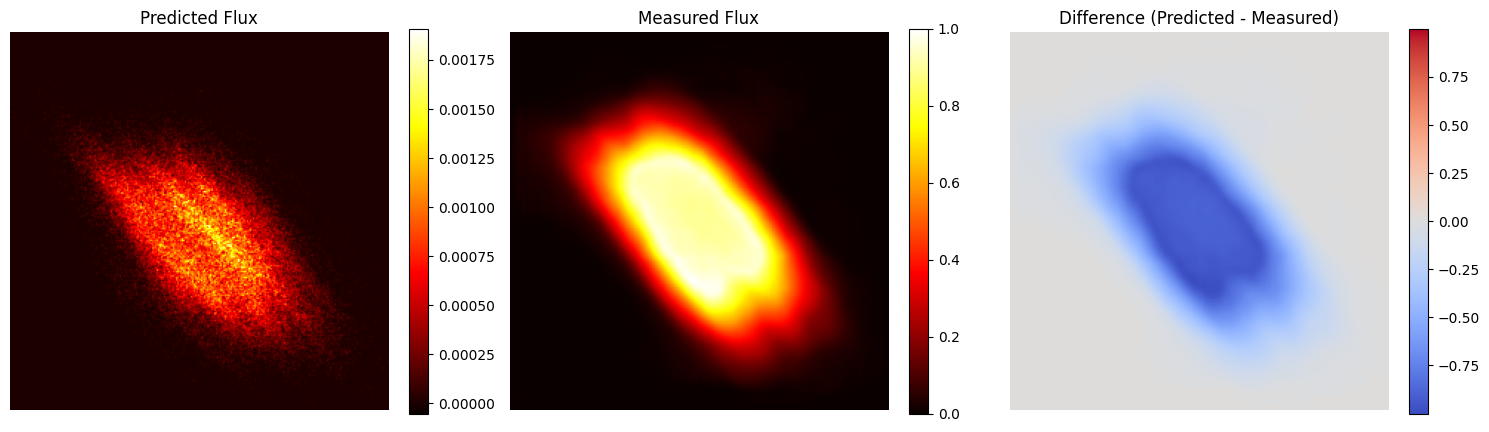

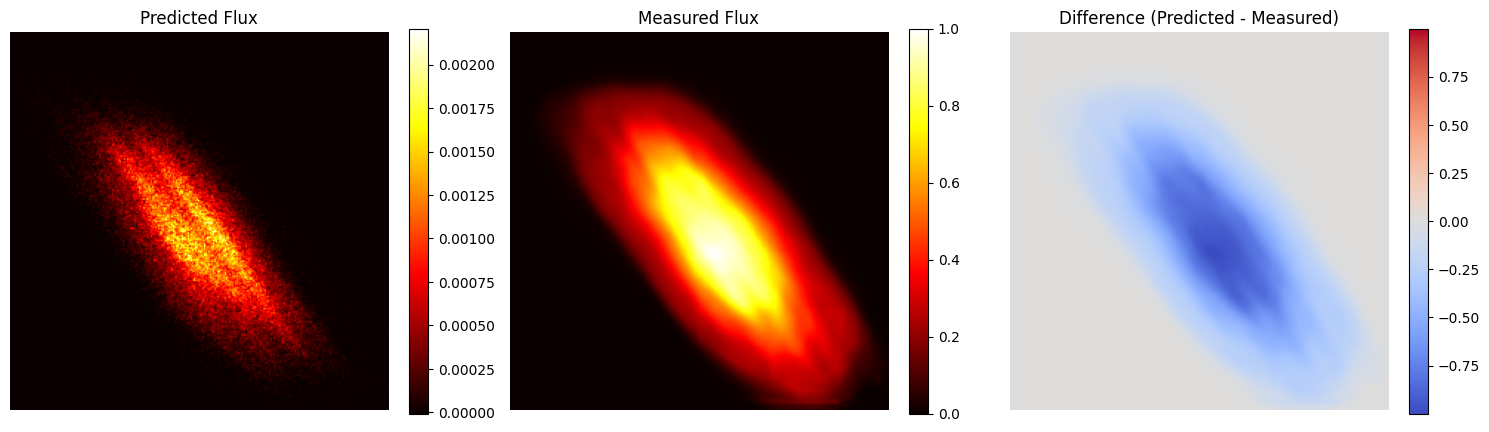

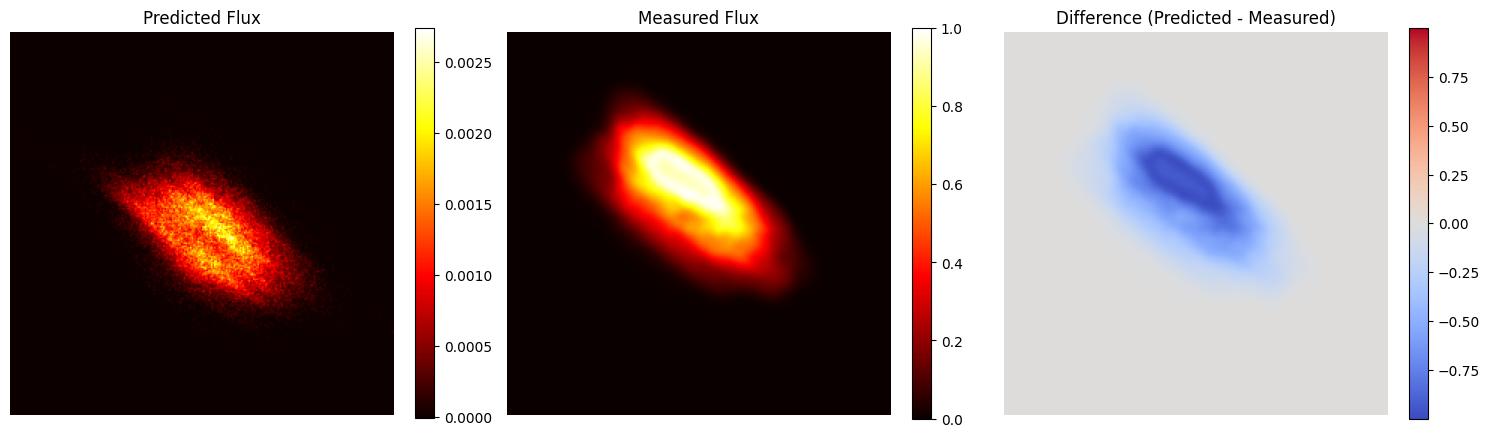

Visualized 5 flux comparison images


In [24]:
print("Generating flux comparison visualizations...")

visualize_flux_comparison(
    scenario=scenario,
    heliostat_data_mapping=test_mapping,
    data_parser=eval_data_parser,
    device=device,
    output_dir=OUTPUT_DIR / "visualizations",
    num_samples=5,
    save_figures=False,  # Set to True to also save to disk
)

## 13. Save Results

In [28]:
import json

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save the optimized kinematic parameters for each heliostat group
print("Saving optimized kinematic parameters...")
kinematic_params_dir = OUTPUT_DIR / "kinematic_parameters"
kinematic_params_dir.mkdir(parents=True, exist_ok=True)

all_kinematic_params = {}
for group_index, heliostat_group in enumerate(scenario.heliostat_field.heliostat_groups):
    group_name = f"group_{group_index}"
    group_params = {
        "rotation_deviation_parameters": heliostat_group.kinematic.rotation_deviation_parameters.detach().cpu(),
        "actuator_parameters": heliostat_group.kinematic.actuators.optimizable_parameters.detach().cpu(),
        "heliostat_names": heliostat_group.names,  # Store heliostat names for reference
    }
    all_kinematic_params[group_name] = group_params

    # Save individual group parameters
    torch.save(group_params, kinematic_params_dir / f"{group_name}_kinematic_params.pt")

# Save all parameters in one file
torch.save(all_kinematic_params, OUTPUT_DIR / "all_kinematic_parameters.pt")
print(f"Saved kinematic parameters to {OUTPUT_DIR / 'all_kinematic_parameters.pt'}")

print("\nNote: The optimized kinematic parameters are saved above.")
print("To use these optimized parameters, load them and apply to a new scenario.")
print("ARTIST does not currently support saving a complete scenario back to HDF5 after modification.")

Saving optimized kinematic parameters...
Saved kinematic parameters to /Users/alexandru/Master Thesis/master-thesis/src/kinematic_reconstruction_results/all_kinematic_parameters.pt

Note: The optimized kinematic parameters are saved above.
To use these optimized parameters, load them and apply to a new scenario.
ARTIST does not currently support saving a complete scenario back to HDF5 after modification.


In [29]:
# Save metrics
metrics_file = OUTPUT_DIR / "test_metrics.json"
with open(metrics_file, "w") as f:
    serializable_metrics = {
        k: v for k, v in test_metrics.items() if k != "per_heliostat"
    }
    serializable_metrics["per_heliostat"] = test_metrics["per_heliostat"]
    json.dump(serializable_metrics, f, indent=2)

print(f"Saved metrics to {metrics_file}")

Saved metrics to /Users/alexandru/Master Thesis/master-thesis/src/kinematic_reconstruction_results/test_metrics.json


In [30]:
# Save final losses
torch.save(final_loss_per_heliostat, OUTPUT_DIR / "final_loss_per_heliostat.pt")
print(f"Saved final losses to {OUTPUT_DIR / 'final_loss_per_heliostat.pt'}")

print("\nDone!")

Saved final losses to /Users/alexandru/Master Thesis/master-thesis/src/kinematic_reconstruction_results/final_loss_per_heliostat.pt

Done!
